# RANDOM FOREST EXPERIMENTATION

In [1]:
from HelperFunctions import shift_axis
import matplotlib.pyplot as plt
import h5py
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

Applying shift_axis transformation to training_data/raman_training.h5...
Applying shift_axis transformation to training_data/raman_test.h5...

--- Training on Original Spectra ---
Accuracy (Original): 0.3700

--- Training on Shifted Spectra ---
Accuracy (Shifted): 0.4135


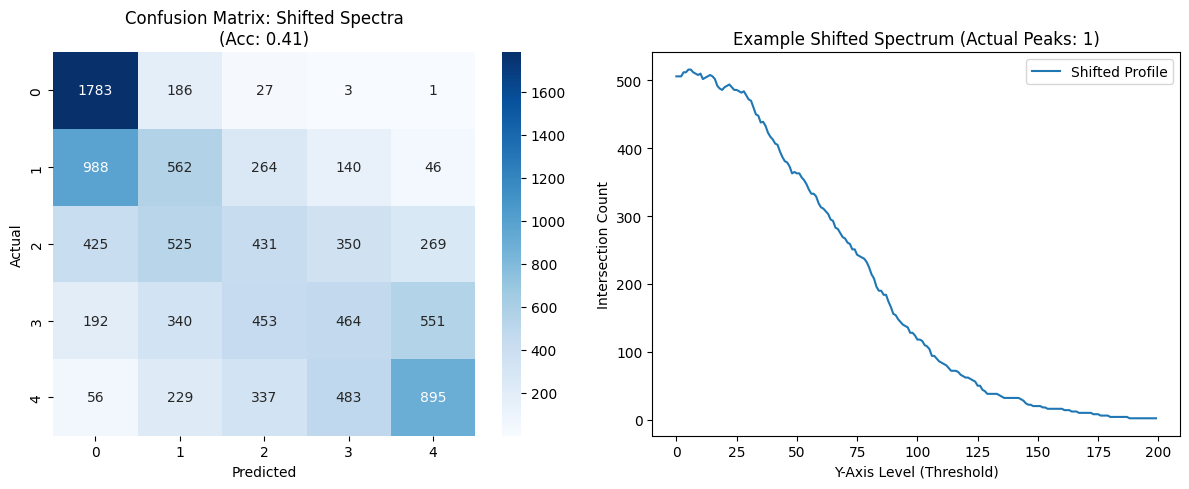

In [3]:
def load_and_preprocess(filename, transform=False):
    with h5py.File(filename, 'r') as hf:
        X = hf['y_values'][:]
        y = hf['num_peaks'][:]
    
    if transform:
        print(f"Applying shift_axis transformation to {filename}...")
        X = np.array([shift_axis(spectrum, resolution=200) for spectrum in X])
    
    return X, y

# Load Data
X_train_orig, y_train = load_and_preprocess("training_data/raman_training.h5", transform=False)
X_test_orig, y_test = load_and_preprocess("training_data/raman_test.h5", transform=False)

X_train_shift, _ = load_and_preprocess("training_data/raman_training.h5", transform=True)
X_test_shift, _ = load_and_preprocess("training_data/raman_test.h5", transform=True)

# Setup Random Forest Models
rf_orig = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42, criterion='gini')
rf_shift = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42, criterion='gini')

# Train and Evaluate: Original Data
print("\n--- Training on Original Spectra ---")
rf_orig.fit(X_train_orig, y_train)
y_pred_orig = rf_orig.predict(X_test_orig)
acc_orig = accuracy_score(y_test, y_pred_orig)
print(f"Accuracy (Original): {acc_orig:.4f}")

# 4. Train and Evaluate: Shifted Data
print("\n--- Training on Shifted Spectra ---")
rf_shift.fit(X_train_shift, y_train)
y_pred_shift = rf_shift.predict(X_test_shift)
acc_shift = accuracy_score(y_test, y_pred_shift)
print(f"Accuracy (Shifted): {acc_shift:.4f}")

# Comparative Visualization
plt.figure(figsize=(12, 5))

# Shifted Data
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_shift), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix: Shifted Spectra\n(Acc: {acc_shift:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Example of shifted spectrum
plt.subplot(1, 2, 2)
sample_idx = 0
plt.plot(X_train_shift[sample_idx], label="Shifted Profile")
plt.title(f"Example Shifted Spectrum (Actual Peaks: {y_train[sample_idx]})")
plt.xlabel("Y-Axis Level (Threshold)")
plt.ylabel("Intersection Count")
plt.legend()

plt.tight_layout()
plt.show()

Text(120.72222222222221, 0.5, 'Actual')

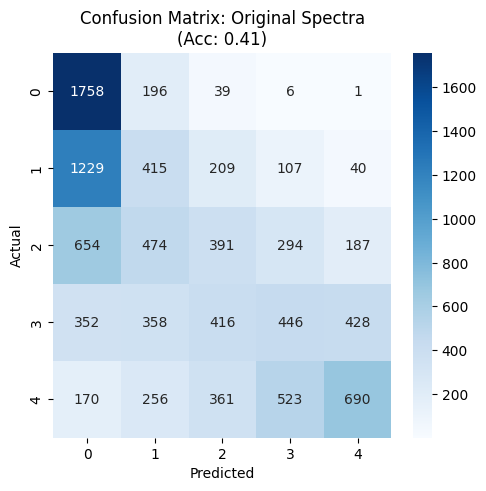

In [4]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_orig), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix: Original Spectra\n(Acc: {acc_shift:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")